# CVaR / Expected Shortfall

**pyportfolios.com tutorial T10** · HYG + VWO, Jan 2007 – Dec 2024 · SciPy · Riskfolio-Lib

Value-at-Risk answers "how bad is the threshold?"; expected shortfall (CVaR) answers
"how bad is it *beyond* the threshold?" — which is what actually hurts. In this notebook we

1. build two synthetic P&L histories with **identical 99% VaR** but wildly different tails,
2. estimate 97.5% / 99% VaR and CVaR for HYG, VWO and a 50/50 mix — historical and
   Student-t parametric (Acerbi's closed form),
3. show CVaR is subadditive where VaR can fail (the coherence property Basel cared about),
4. zoom into HYG through the GFC, and
5. compare CVaR-optimal vs mean-variance weights with Riskfolio-Lib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)

## 1 · Data: two fat-tailed assets

HYG (iShares high-yield corporate bond ETF) and VWO (Vanguard emerging-markets equity):
low-vol-looking credit and honest EM volatility, both with tails a normal distribution
cannot describe. The sample includes the GFC, the 2011 EM selloff, the COVID crash and
the 2022 rate shock. HYG listed in April 2007, so the aligned sample starts there.

In [2]:
px = yf.download(["HYG", "VWO"], start="2007-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].dropna()
rets = px.pct_change().dropna()
rets["PORT"] = 0.5 * rets["HYG"] + 0.5 * rets["VWO"]   # daily-rebalanced 50/50
rets.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Ticker,,,,
HYG,0.000210,0.007079,-0.080974,0.122689
VWO,0.000273,0.017043,-0.153423,0.202823
PORT,0.000242,0.011037,-0.098529,0.162756


## 2 · What VaR cannot see

Two 1,000-day P&L histories that agree on 990 days and on the *10th-worst* day —
so their 99% historical VaR is identical — but whose worst days differ by 6×.
VaR is a quantile: it reads the threshold and is blind to everything beyond it.
CVaR is the **mean of the tail**, so it sees the difference immediately.

In [3]:
def var_hist(x, a):
    return -np.quantile(x, 1 - a)

def cvar_hist(x, a):
    q = np.quantile(x, 1 - a)
    return -x[x <= q].mean()

body   = np.linspace(-0.024, 0.024, 990)          # identical benign body
tail_a = np.full(10, -0.026)                      # thin tail
tail_b = np.array([-0.026, -0.03, -0.04, -0.05, -0.06,
                   -0.07, -0.08, -0.10, -0.12, -0.15])   # fat tail
da, db = np.r_[body, tail_a], np.r_[body, tail_b]

for name, d in [("thin tail", da), ("fat tail", db)]:
    print(f"{name}: 99% VaR = {var_hist(d, .99):.2%}   99% CVaR = {cvar_hist(d, .99):.2%}")

thin tail: 99% VaR = 2.40%   99% CVaR = 2.60%
fat tail: 99% VaR = 2.40%   99% CVaR = 7.26%


## 3 · Historical & Student-t VaR / CVaR

Historical estimates read the empirical distribution directly. The parametric route fits
a Student-t (fat tails, three parameters) and uses **Acerbi's closed-form expected
shortfall** for the t:

$$\mathrm{ES}_p = -\mu + \sigma\,\frac{f_\nu(x_p)\,(\nu + x_p^2)}{(\nu-1)\,p},
\qquad x_p = F_\nu^{-1}(p),\ p = 1-\alpha.$$

We report both at 97.5% and 99% — 97.5% ES is the FRTB standard, 99% VaR the old one.

In [4]:
def var_t(params, a):
    nu, loc, scale = params
    return -(loc + scale * stats.t.ppf(1 - a, nu))

def cvar_t(params, a):                      # Acerbi & Tasche closed form
    nu, loc, scale = params
    p = 1 - a
    xp = stats.t.ppf(p, nu)
    return -loc + scale * stats.t.pdf(xp, nu) * (nu + xp**2) / ((nu - 1) * p)

rows = []
for c in ["HYG", "VWO", "PORT"]:
    x = rets[c].values
    fit = stats.t.fit(x)
    rows.append({
        "asset": c, "nu": fit[0],
        "hist VaR99": var_hist(x, .99),  "hist CVaR99": cvar_hist(x, .99),
        "t VaR99":    var_t(fit, .99),   "t CVaR99":    cvar_t(fit, .99),
        "hist CVaR97.5": cvar_hist(x, .975),
        "CVaR/VaR": cvar_hist(x, .99) / var_hist(x, .99),
        "worst day": x.min(),
    })
pd.DataFrame(rows).set_index("asset").round(4)

,nu,hist VaR99,hist CVaR99,t VaR99,t CVaR99,hist CVaR97.5,CVaR/VaR,worst day
asset,,,,,,,,
HYG,1.9798,0.0209,0.0337,0.0199,0.0409,0.0229,1.6158,-0.0810
VWO,2.9255,0.0486,0.0715,0.0456,0.0715,0.0518,1.4714,-0.1534
PORT,2.6344,0.0326,0.0492,0.0300,0.0497,0.0345,1.5088,-0.0985


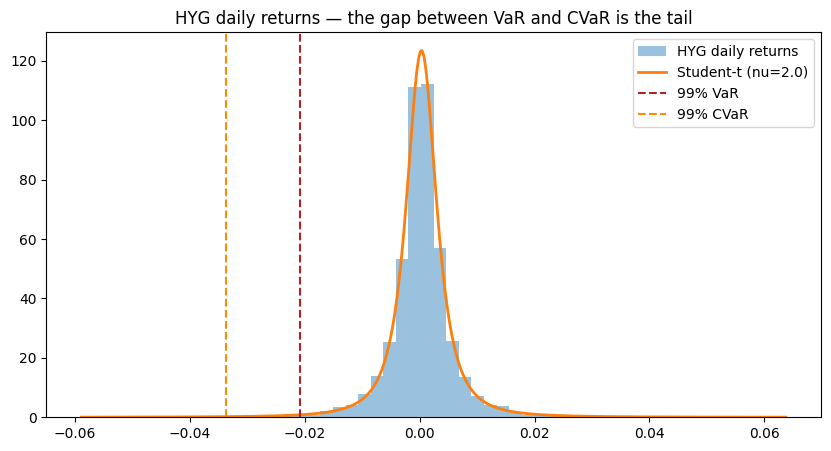

In [5]:
x = rets["HYG"].values
nu, loc, scale = stats.t.fit(x)
edges = np.linspace(np.quantile(x, 0.0005), np.quantile(x, 0.9995), 57)
plt.hist(x, bins=edges, density=True, alpha=0.45, label="HYG daily returns")
grid = np.linspace(edges[0], edges[-1], 400)
plt.plot(grid, stats.t.pdf(grid, nu, loc, scale), lw=2, label=f"Student-t (nu={nu:.1f})")
plt.axvline(-var_hist(x, .99),  ls="--", c="firebrick", label="99% VaR")
plt.axvline(-cvar_hist(x, .99), ls="--", c="darkorange", label="99% CVaR")
plt.legend(); plt.title("HYG daily returns — the gap between VaR and CVaR is the tail");

## 4 · Subadditivity — the coherence test

Artzner et al. (1999) demand of a *coherent* risk measure that diversification never
increases it: $\rho(A+B) \le \rho(A) + \rho(B)$. CVaR always passes; VaR can fail.
The classic counterexample: two independent bonds, each defaulting with probability
0.7%. Alone, each has **zero** 99% VaR (P(loss) < 1%). A 50/50 mix loses on
$1 - 0.993^2 = 1.39\%$ of scenarios — above 1% — so the diversified portfolio has
*positive* 99% VaR. Diversification "created" risk, according to VaR.

In [6]:
# empirical check on HYG/VWO at 99% (full sample)
for name, fn in [("VaR", var_hist), ("CVaR", cvar_hist)]:
    port  = fn(rets["PORT"].values, .99)
    blend = 0.5 * fn(rets["HYG"].values, .99) + 0.5 * fn(rets["VWO"].values, .99)
    print(f"99% {name}: portfolio = {port:.2%}   0.5·HYG + 0.5·VWO = {blend:.2%}"
          f"   subadditive: {port <= blend}")

# historical VaR violates subadditivity in calendar-year subsamples
hits = []
for y in range(2008, 2025):
    w = rets.loc[str(y)]
    for a in np.arange(0.90, 0.9951, 0.0025):
        vp = var_hist(w["PORT"].values, a)
        vb = 0.5 * var_hist(w["HYG"].values, a) + 0.5 * var_hist(w["VWO"].values, a)
        if vp > vb:
            hits.append((y, round(a, 4), vp, vb))
print(f"\nyear-level VaR subadditivity violations: {len(hits)}")
for y, a, vp, vb in sorted(hits, key=lambda t: t[3] - t[2])[:3]:
    print(f"  {y} @ alpha={a}: VaR(port) = {vp:.2%} > blend = {vb:.2%}")

# CVaR never violates — try it
assert not [1 for y, a, _, _ in hits
            if cvar_hist(rets.loc[str(y), "PORT"].values, a) >
               0.5 * cvar_hist(rets.loc[str(y), "HYG"].values, a)
             + 0.5 * cvar_hist(rets.loc[str(y), "VWO"].values, a)]

99% VaR: portfolio = 3.26%   0.5·HYG + 0.5·VWO = 3.47%   subadditive: True
99% CVaR: portfolio = 4.92%   0.5·HYG + 0.5·VWO = 5.26%   subadditive: True



year-level VaR subadditivity violations: 64
  2009 @ alpha=0.9875: VaR(port) = 4.48% > blend = 3.95%
  2009 @ alpha=0.985: VaR(port) = 4.30% > blend = 3.87%
  2009 @ alpha=0.99: VaR(port) = 4.54% > blend = 4.23%


## 5 · The GFC, seen from the tail

HYG's full-sample 99% VaR is a number the GFC ignored. Count the exceedances from
September 2008 to March 2009 against what a 1% tail should deliver.

2008-09-29  -8.10%
2008-10-10  -6.67%
2008-09-17  -6.01%
2008-10-27  -5.09%
2009-03-05  -4.74%

days beyond full-sample 99% VaR in Sep-08..Mar-09: 24 of 146 (expected ~1.5)


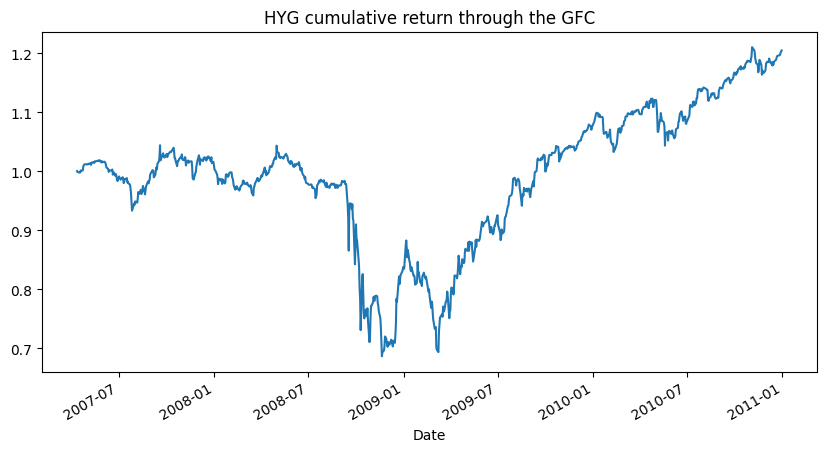

In [7]:
gwin = rets.loc["2007":"2010", "HYG"]
(1 + gwin).cumprod().plot(title="HYG cumulative return through the GFC")
for d, ret in gwin.nsmallest(5).items():
    print(f"{d.date()}  {ret: .2%}")

crisis = rets.loc["2008-09":"2009-03", "HYG"]
var99 = var_hist(rets["HYG"].values, .99)
print(f"\ndays beyond full-sample 99% VaR in Sep-08..Mar-09: "
      f"{(crisis < -var99).sum()} of {len(crisis)} (expected ~{0.01*len(crisis):.1f})")

## 6 · CVaR-optimal vs mean-variance allocation (Riskfolio-Lib)

With only two assets, pure MinRisk corners at 100% HYG under *both* measures — vol and
tail agree on which asset is the quieter one. The measures diverge the moment you spend
a **risk budget**. Give both desks the same mandate — "your expected loss on the worst
1% of days may not exceed 4%" — and let each maximise return against it:

- the **MV desk** translates the budget into a vol cap via normality
  ($\mathrm{ES}_{99\%} = 2.665\,\sigma$ for a Gaussian), then optimises with `rm="MV"`;
- the **CVaR desk** constrains the realized 99% CVaR directly with `rm="CVaR"`.

Because both assets' tails are fatter than normal, the vol-translated budget is far too
generous — the MV desk loads up on VWO and quietly blows through the true tail budget.

In [8]:
import riskfolio as rp
from scipy import stats as st

BUDGET = 0.04                                    # 99% ES budget, daily
sig_budget = BUDGET / (st.norm.pdf(st.norm.ppf(0.01)) / 0.01)   # = BUDGET / 2.665
Y = rets[["HYG", "VWO"]]

p_mv = rp.Portfolio(returns=Y)
p_mv.assets_stats(method_mu="hist", method_cov="hist")
p_mv.upperdev = sig_budget                       # normal-translated vol cap
w_mv = p_mv.optimization(model="Classic", rm="MV", obj="MaxRet", hist=True)

p_cv = rp.Portfolio(returns=Y)
p_cv.assets_stats(method_mu="hist", method_cov="hist")
p_cv.alpha = 0.01
p_cv.upperCVaR = BUDGET                          # the tail budget itself
w_cv = p_cv.optimization(model="Classic", rm="CVaR", obj="MaxRet", hist=True)

for name, w in [("MV desk (vol-translated budget)", w_mv), ("CVaR desk", w_cv)]:
    pr = (Y * w["weights"].values).sum(axis=1).values
    print(f"{name}: HYG {w.loc['HYG', 'weights']:.1%} / VWO {w.loc['VWO', 'weights']:.1%}"
          f" -> realized 99% CVaR {cvar_hist(pr, .99):.2%} vs budget {BUDGET:.0%}")

MV desk (vol-translated budget): HYG 16.2% / VWO 83.8% -> realized 99% CVaR 6.37% vs budget 4%
CVaR desk: HYG 75.3% / VWO 24.7% -> realized 99% CVaR 3.99% vs budget 4%


## Takeaways

- VaR is a quantile: it prices the door to the tail, not what is behind it. Two books
  with identical 99% VaR can differ 3× in expected tail loss.
- CVaR is coherent — subadditive by construction — while VaR can punish diversification
  (the two-bond example). This is why Basel's FRTB replaced 99% VaR with 97.5% ES.
- HYG is the poster child: modest volatility, brutal CVaR/VaR ratio. Credit smiles now
  and cries later; variance-based tools systematically over-allocate to it.
- Spend the same tail budget through a variance lens and a CVaR lens and you get very
  different books (≈84% vs ≈25% VWO here) — the vol-translated budget ignores exactly
  the tail it was meant to cap.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*